In [2]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import theilslopes

### read in exceedance dataframes

In [3]:
ari = 1000
duration = 24

version = "v2.0"  ### version of our dataset

In [4]:
if duration > 24:
    st4 = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/stage4/stage4_2002-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    st4 = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/stage4/stage4_2002-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
st4['time'] = pd.to_datetime(st4['time'])

if duration > 24:
    prism = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/prism/prism_1981-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    prism = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/prism/prism_1981-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
prism['time'] = pd.to_datetime(prism['time'])

if duration > 24:
    conus404 = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/conus404/conus404_1981-2022_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    conus404 = pd.read_csv("/glade/work/rschumac/precip_data/extremerain/"+version+"/conus404/conus404_1981-2022_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
conus404['time'] = pd.to_datetime(conus404['time'])

if duration > 24:
    mrms = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/mrms/mrms_2018-2024_events_"+str(ari)+"y"+str(duration)+"h_edit_nooverlaps.csv")
else:
    mrms = pd.read_csv("//glade/work/rschumac/precip_data/extremerain/"+version+"/mrms/mrms_2018-2024_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")
mrms['time'] = pd.to_datetime(mrms['time'])

conus404

,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
0,1981-05-26 12:00:00,41.25000,-113.70833,72.209,0.682,1.00953,2
1,1981-06-14 12:00:00,40.00000,-86.91667,220.879,2.301,1.01053,0
2,1981-06-14 12:00:00,40.04167,-86.91667,219.691,3.044,1.01405,0
3,1981-06-14 12:00:00,40.04167,-86.87500,228.600,12.931,1.05996,0
4,1981-06-14 12:00:00,40.04167,-86.83333,231.661,14.201,1.06530,0
...,...,...,...,...,...,...,...
6961,2022-09-29 12:00:00,29.08333,-81.04167,610.690,104.656,1.20682,0
6962,2022-09-29 12:00:00,29.08333,-81.00000,530.059,13.956,1.02704,0
6963,2022-09-29 12:00:00,29.12500,-81.12500,524.815,31.395,1.06363,0
6964,2022-09-29 12:00:00,29.12500,-81.08333,555.392,56.345,1.11290,0


## 2-panel, PRISM vs CONUS404 over longer period, ST4 vs CONUS404 over shorter period, monthly distribution

In [5]:
prism_sub = prism[prism.time < pd.Timestamp(2022,10,1,0)]

### make a combined dataframe that has the 'month' column along with an identifier of the dataset
prism_monthdist = pd.DataFrame(prism_sub.time.dt.month)
prism_monthdist['dataset'] = 'PRISM'

conus404_monthdist = pd.DataFrame(conus404.time.dt.month)
conus404_monthdist['dataset'] = 'CONUS404'

monthdist_long = pd.concat([prism_monthdist,conus404_monthdist])

### shorter period
st4_sub = st4[st4.time < pd.Timestamp(2022,10,1,0)]
conus404_sub = conus404[(conus404.time >= pd.Timestamp(2002,1,1,0))]

### make a combined dataframe that has the 'month' column along with an identifier of the dataset
st4_monthdist = pd.DataFrame(st4_sub.time.dt.month)
st4_monthdist['dataset'] = 'Stage IV'

conus404_sub_monthdist = pd.DataFrame(conus404_sub.time.dt.month)
conus404_sub_monthdist['dataset'] = 'CONUS404'

monthdist_short = pd.concat([st4_monthdist,conus404_sub_monthdist])

monthdist_short



,time,dataset
0,3,Stage IV
1,3,Stage IV
2,7,Stage IV
3,7,Stage IV
4,7,Stage IV
...,...,...
6961,9,CONUS404
6962,9,CONUS404
6963,9,CONUS404
6964,9,CONUS404


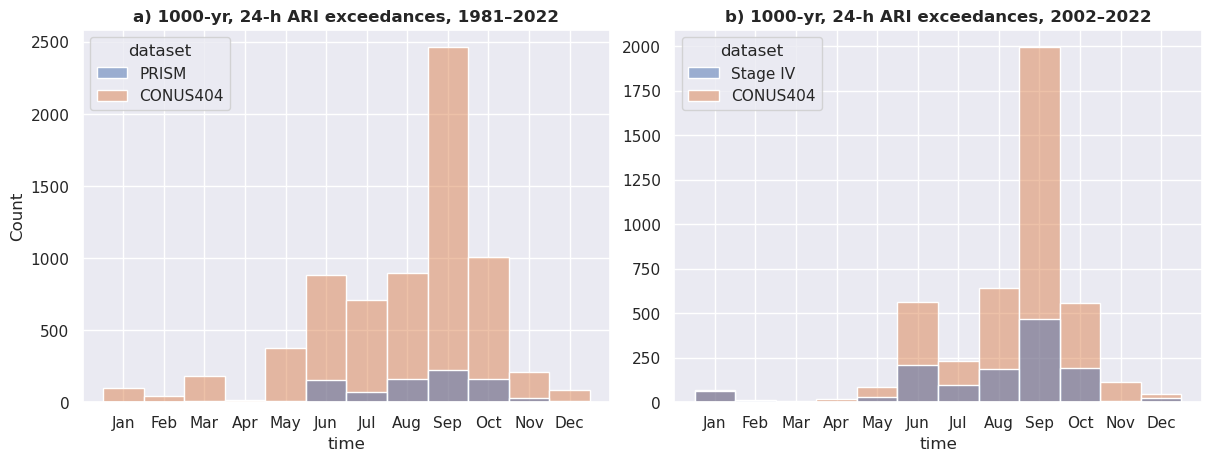

In [6]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(monthdist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(13) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['long'].set_xticks(range(1,13),months)
axes['long'].set_xlim([0, 13])

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(13) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['short'].set_xticks(range(1,13),months)
axes['short'].set_xlim([0, 13])
axes['short'].set_ylabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("monthly_dist_compare_2panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()

plt.close('all')

## repeat, but make it 4-panel with the number of events also

In [7]:
prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_monthdist_events = pd.DataFrame(prism_unique_events.time.unique().month)
prism_monthdist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_monthdist_events = pd.DataFrame(conus404_unique_events.time.unique().month)
conus404_monthdist_events['dataset'] = 'CONUS404'

monthdist_events_long = pd.concat([prism_monthdist_events,conus404_monthdist_events])
monthdist_events_long.columns=['month','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_monthdist_events = pd.DataFrame(st4_unique_events.time.unique().month)
st4_monthdist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_monthdist_events = pd.DataFrame(conus404_unique_events.time.unique().month)
conus404_sub_monthdist_events['dataset'] = 'CONUS404'

monthdist_events_short = pd.concat([st4_monthdist_events,conus404_sub_monthdist_events])
monthdist_events_short.columns=['month','dataset']

monthdist_events_long

,month,dataset
0,12,PRISM
1,7,PRISM
2,3,PRISM
3,9,PRISM
4,10,PRISM
...,...,...
490,8,CONUS404
491,8,CONUS404
492,9,CONUS404
493,9,CONUS404


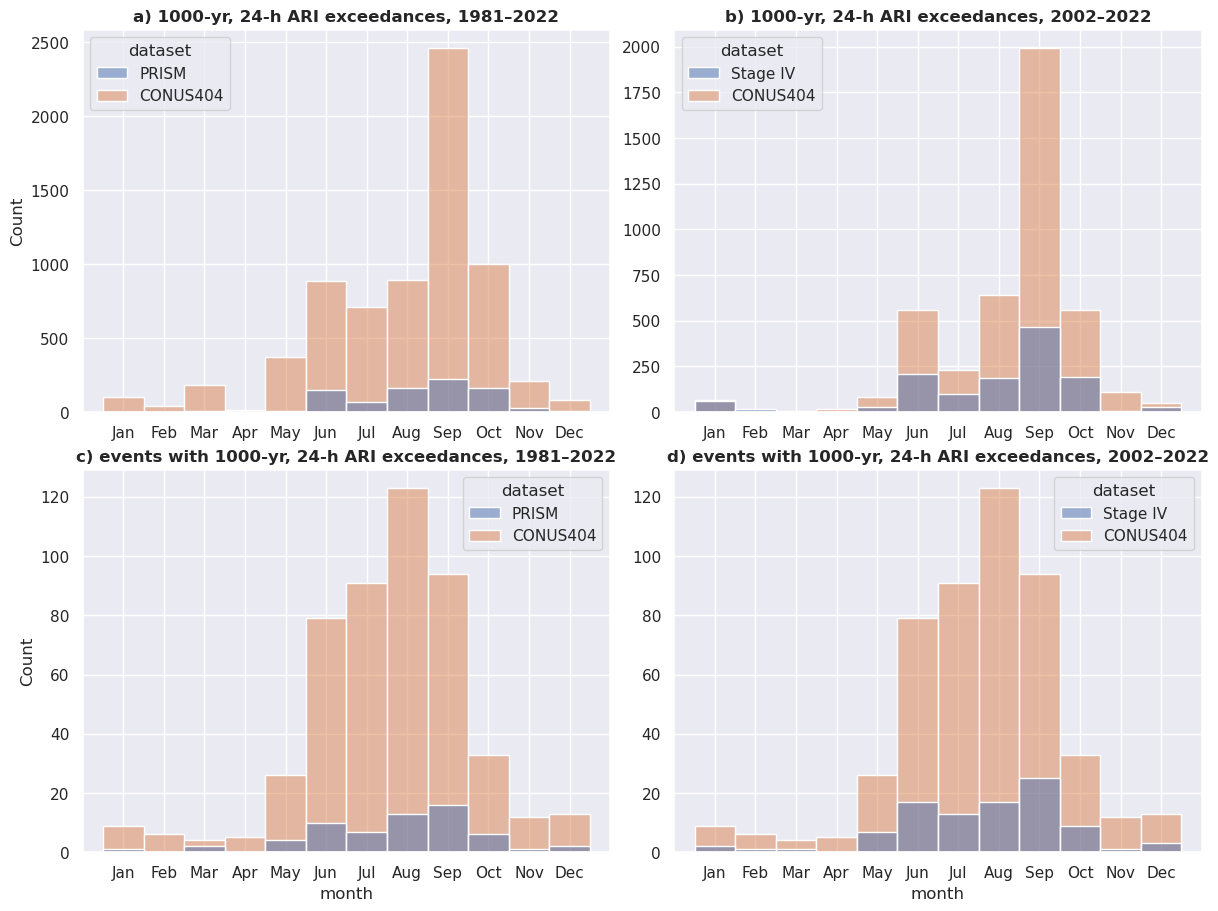

In [8]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short']], figsize=(12,9),
                              constrained_layout=True)

sns.histplot(monthdist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(13) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['long'].set_xticks(range(1,13),months)
axes['long'].set_xlim([0, 13])
axes['long'].set_xlabel('')

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(13) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['short'].set_xticks(range(1,13),months)
axes['short'].set_xlim([0, 13])
axes['short'].set_ylabel('')
axes['short'].set_xlabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

### events
sns.histplot(monthdist_events_long, x='month', hue='dataset', ax=axes['events_long'],
             bins = np.arange(13) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_long'].set_xticks(range(1,13),months)
axes['events_long'].set_xlim([0, 13])

### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(monthdist_events_short, x='month', hue='dataset', ax=axes['events_short'],
             bins = np.arange(13) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                  fontdict={'weight': 'semibold'})
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes['events_short'].set_xticks(range(1,13),months)
axes['events_short'].set_xlim([0, 13])
axes['events_short'].set_ylabel('')

#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("monthly_dist_compare_4panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()

plt.close('all')

## 4-panel, time series of exceedance comparison on top; event number comparison on bottom

In [9]:
prism_yeardist = pd.DataFrame(prism_sub.time.dt.year)
prism_yeardist['dataset'] = 'PRISM'

conus404_yeardist = pd.DataFrame(conus404.time.dt.year)
conus404_yeardist['dataset'] = 'CONUS404'

yeardist_long = pd.concat([prism_yeardist,conus404_yeardist])

st4_yeardist = pd.DataFrame(st4_sub.time.dt.year)
st4_yeardist['dataset'] = 'Stage IV'

conus404_sub_yeardist = pd.DataFrame(conus404_sub.time.dt.year)
conus404_sub_yeardist['dataset'] = 'CONUS404'

yeardist_short = pd.concat([st4_yeardist,conus404_sub_yeardist])

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_long = pd.concat([prism_yeardist_events,conus404_yeardist_events])
yeardist_events_long.columns=['year','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_sub_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_short = pd.concat([st4_yeardist_events,conus404_sub_yeardist_events])
yeardist_events_short.columns=['year','dataset']

yeardist_events_short



,year,dataset
0,2002,Stage IV
1,2002,Stage IV
2,2002,Stage IV
3,2002,Stage IV
4,2002,Stage IV
...,...,...
490,2022,CONUS404
491,2022,CONUS404
492,2022,CONUS404
493,2022,CONUS404


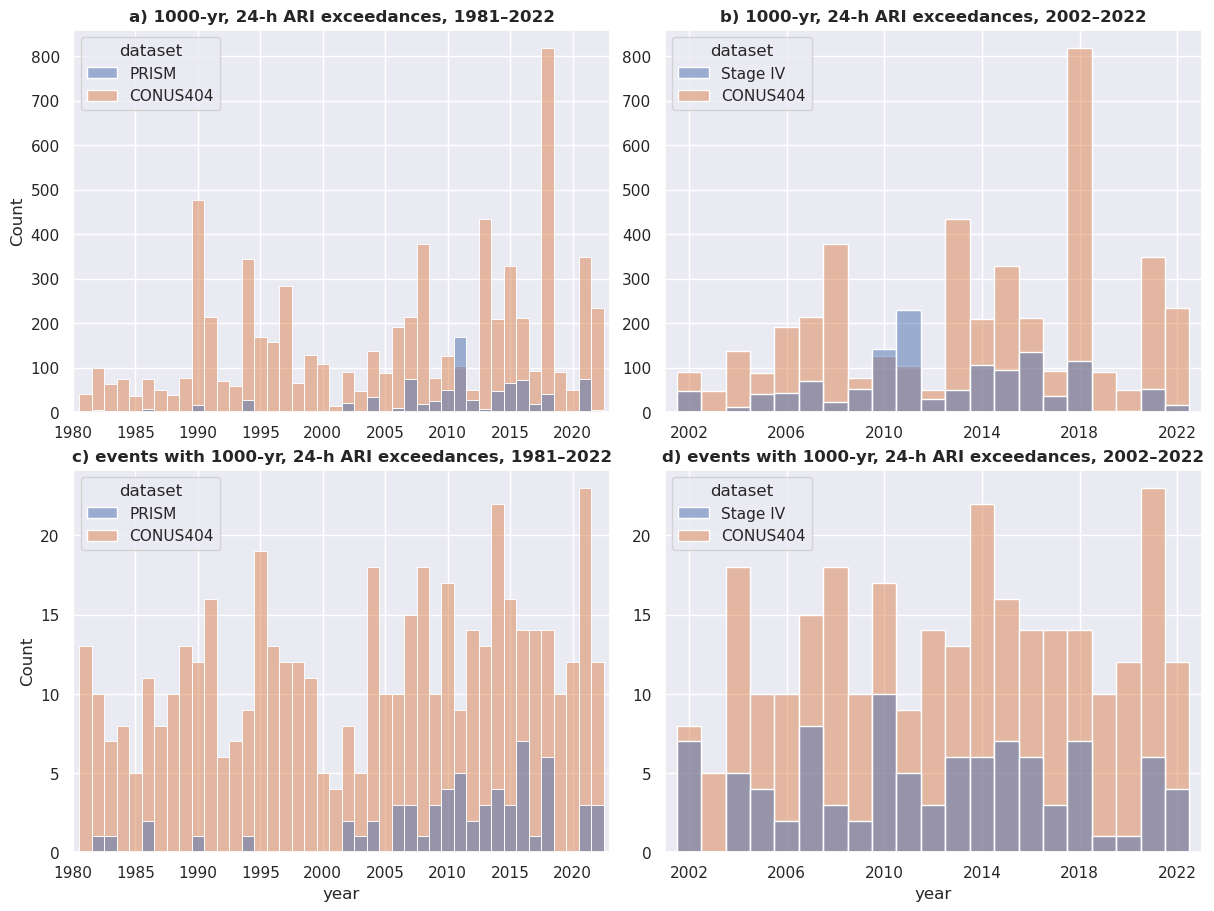

In [10]:
sns.set_theme()

fig, axes = plt.subplot_mosaic([['long','short'],
                               ['events_long','events_short']], figsize=(12,9),
                              constrained_layout=True)

sns.histplot(yeardist_long, x='time', hue='dataset', ax=axes['long'],
             bins = np.arange(1980,2023) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['long'].set_xlim([1980, 2023])
axes['long'].set_xlabel('')

sns.histplot(yeardist_short, x='time', hue='dataset', ax=axes['short'],
             bins = np.arange(2001,2023) + 0.5).set_title("b) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['short'].set_xlim([2001, 2023])
axes['short'].set_xticks(range(2002,2023,4))
axes['short'].set_xlabel('')
axes['short'].set_ylabel('')

sns.histplot(yeardist_events_long, x='year', hue='dataset', ax=axes['events_long'],
             bins = np.arange(1980,2023) + 0.5).set_title("c) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_long'].set_xlim([1980, 2023])

sns.histplot(yeardist_events_short, x='year', hue='dataset', ax=axes['events_short'],
             bins = np.arange(2001,2023) + 0.5).set_title("d) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['events_short'].set_xlim([2001, 2023])
axes['events_short'].set_xticks(range(2002,2023,4))
axes['events_short'].set_ylabel('')

plt.savefig("annual_dist_compare_4panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')

plt.show()
plt.close('all')



## 2-panel, PRISM vs Stage IV, 2002-2024

In [11]:
st4_sub = st4[st4.time < pd.Timestamp(2025,1,1,0)]
prism_sub = prism[(prism.time >= pd.Timestamp(2002,1,1,0))]

st4_yeardist = pd.DataFrame(st4_sub.time.dt.year)
st4_yeardist['dataset'] = 'Stage IV'

prism_yeardist = pd.DataFrame(prism_sub.time.dt.year)
prism_yeardist['dataset'] = 'PRISM'

yeardist = pd.concat([prism_yeardist,st4_yeardist])

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

yeardist_events = pd.concat([prism_yeardist_events,st4_yeardist_events])
yeardist_events.columns=['year','dataset']

yeardist_events


,year,dataset
0,2002,PRISM
1,2002,PRISM
2,2003,PRISM
3,2004,PRISM
4,2004,PRISM
...,...,...
105,2024,Stage IV
106,2024,Stage IV
107,2024,Stage IV
108,2024,Stage IV


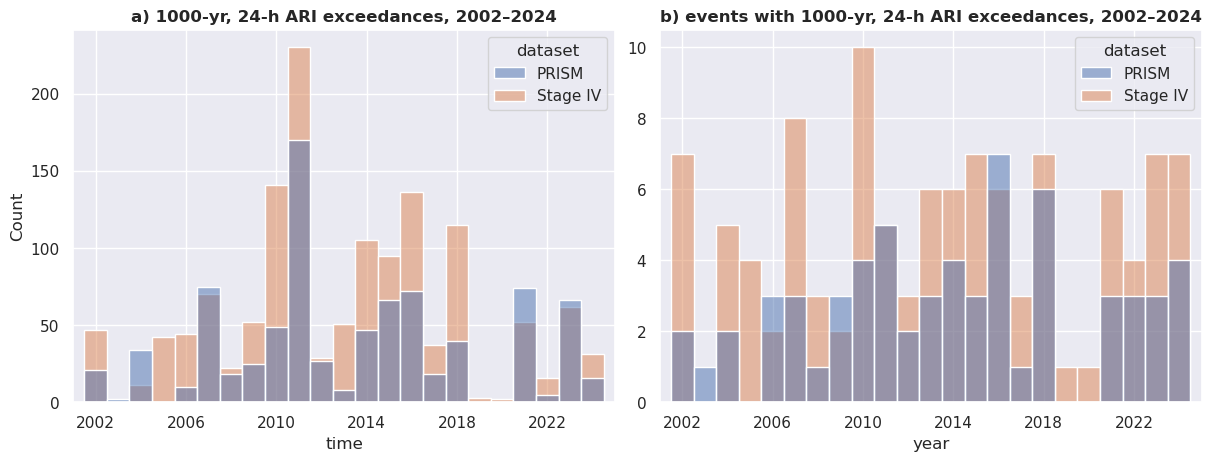

In [12]:
fig, axes = plt.subplot_mosaic([['exceed','events']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(yeardist, x='time', hue='dataset', ax=axes['exceed'],
             bins = np.arange(2001,2025) + 0.5).set_title("a) "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132024",
                                                         fontdict={'weight': 'semibold'})
axes['exceed'].set_xticks(range(2002,2025,4))
axes['exceed'].set_xlim(2001,2025)

sns.histplot(yeardist_events, x='year', hue='dataset', ax=axes['events'],
             bins = np.arange(2001,2025) + 0.5).set_title("b) events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132024",
                                                         fontdict={'weight': 'semibold'})
axes['events'].set_xticks(range(2002,2025,4))
axes['events'].set_xlim(2001,2025)
axes['events'].set_ylabel('')

plt.savefig("annual_dist_compare_prism_st4_2panel_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')
plt.show()
plt.close('all')

## 2-panel, SW region

In [13]:
region = "SW"

min_lat_dict = {'PCST': 34.4, 'SW': 31.3, 'ROCK': 39.0, 'SGP': 27.5, 'NGP': 39.0, 'MDWST': 36.5, 'SE': 29.0, 'NE': 36.5, 'FL': 25.0,'CONUS': 25.0}
max_lat_dict = {'PCST': 49.0, 'SW': 39.0, 'ROCK': 49.0, 'SGP': 39.0, 'NGP': 49.0, 'MDWST': 46.5, 'SE': 36.5, 'NE': 45.0, 'FL': 29.0,'CONUS': 49.0}
min_lon_dict = {'PCST': 235.8, 'SW': 240.0, 'ROCK': 240.0, 'SGP': 255.0, 'NGP': 255.0, 'MDWST': 265.4, 'SE': 265.4, 'NE': 279.5, 'FL': 277.0,'CONUS': 235.8}
max_lon_dict = {'PCST': 240.0, 'SW': 255.0, 'ROCK': 255.0, 'SGP': 265.4, 'NGP': 265.4, 'MDWST': 279.5, 'SE': 282.2, 'NE': 290.0, 'FL': 280.2,'CONUS': 290.0}

latmin = min_lat_dict[region]
latmax = max_lat_dict[region]
lonmin = min_lon_dict[region] - 360.
lonmax = max_lon_dict[region] - 360.

print(latmin,latmax,lonmin,lonmax)

st4 = st4[(st4.lon >= lonmin) & (st4.lon <= lonmax) & (st4.lat >= latmin) & (st4.lat <= latmax)] 
conus404 = conus404[(conus404.lon >= lonmin) & (conus404.lon <= lonmax) & (conus404.lat >= latmin) & (conus404.lat <= latmax)] 
prism = prism[(prism.lon >= lonmin) & (prism.lon <= lonmax) & (prism.lat >= latmin) & (prism.lat <= latmax)] 
mrms = mrms[(mrms.lon >= lonmin) & (mrms.lon <= lonmax) & (mrms.lat >= latmin) & (mrms.lat <= latmax)] 

st4

31.3 39.0 -120.0 -105.0


,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
41,2002-11-09 12:00:00,35.50000,-118.41667,254.276,8.844,1.03603,0
42,2002-11-09 12:00:00,35.50000,-118.37500,271.449,19.735,1.07840,0
43,2002-11-09 12:00:00,35.50000,-118.33333,258.395,13.307,1.05429,0
44,2002-11-09 12:00:00,35.54167,-118.37500,274.797,26.783,1.10799,0
45,2002-11-09 12:00:00,35.54167,-118.33333,258.405,5.966,1.02363,0
...,...,...,...,...,...,...,...
1381,2024-06-20 12:00:00,34.58333,-105.83333,153.199,23.377,1.18007,1
1382,2024-06-20 12:00:00,35.75000,-105.25000,162.324,5.377,1.03426,1
1383,2024-06-20 12:00:00,35.79167,-105.33333,159.499,8.753,1.05806,1
1384,2024-06-20 12:00:00,35.79167,-105.29167,178.298,25.764,1.16891,1


In [14]:
prism_sub = prism[prism.time < pd.Timestamp(2022,10,1,0)]
### shorter period
st4_sub = st4[st4.time < pd.Timestamp(2022,10,1,0)]
conus404_sub = conus404[(conus404.time >= pd.Timestamp(2002,1,1,0))]

prism_unique_events = prism_sub.drop_duplicates(subset=['time','event_num'])
prism_yeardist_events = pd.DataFrame(prism_unique_events.time.unique().year)
prism_yeardist_events['dataset'] = 'PRISM'

conus404_unique_events = conus404.drop_duplicates(subset=['time','event_num'])
conus404_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_long = pd.concat([prism_yeardist_events,conus404_yeardist_events])
yeardist_events_long.columns=['year','dataset']

st4_unique_events = st4_sub.drop_duplicates(subset=['time','event_num'])
st4_yeardist_events = pd.DataFrame(st4_unique_events.time.unique().year)
st4_yeardist_events['dataset'] = 'Stage IV'

conus404_sub_unique_events = conus404_sub.drop_duplicates(subset=['time','event_num'])
conus404_sub_yeardist_events = pd.DataFrame(conus404_unique_events.time.unique().year)
conus404_sub_yeardist_events['dataset'] = 'CONUS404'

yeardist_events_short = pd.concat([st4_yeardist_events,conus404_sub_yeardist_events])
yeardist_events_short.columns=['year','dataset']

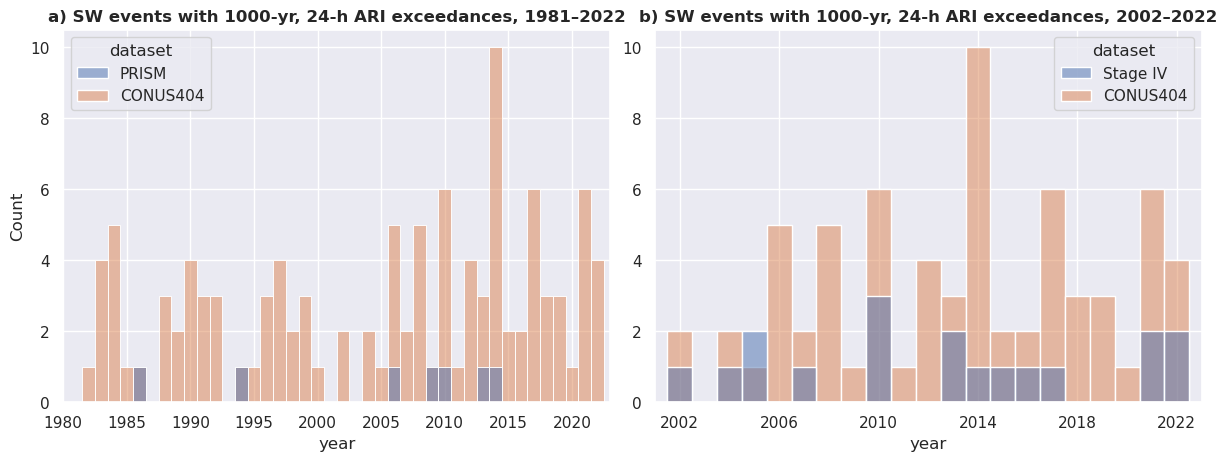

In [20]:
fig, axes = plt.subplot_mosaic([['long','short']], figsize=(12,4.5),
                              constrained_layout=True)

sns.histplot(yeardist_events_long, x='year', hue='dataset', ax=axes['long'],
             bins = np.arange(1980,2023) + 0.5).set_title("a) "+region+" events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 1981\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['long'].set_xlim([1980, 2023])
### put numbers on top of the bars
#axes['long'].bar_label(axes['long'].containers[0])
#axes['long'].bar_label(axes['long'].containers[1])

sns.histplot(yeardist_events_short, x='year', hue='dataset', ax=axes['short'],
             bins = np.arange(2001,2025) + 0.5).set_title("b) "+region+" events with "+str(ari)+"-yr, "+str(duration)+"-h ARI exceedances, 2002\u20132022",
                                                         fontdict={'weight': 'semibold'})
axes['short'].set_xticks(range(2002,2023,4))
axes['short'].set_xlim(2001,2023)
axes['short'].set_ylabel('')
### put numbers on top of the bars
#axes['short'].bar_label(axes['short'].containers[0])
#axes['short'].bar_label(axes['short'].containers[1])

plt.savefig("annual_dist_events_compare_2panel_"+region+"_"+str(ari)+"y"+str(duration)+"h.pdf", dpi=300,
           bbox_inches='tight')
plt.show()
plt.close('all')

In [17]:
prism_yeardist_events

,0,dataset
0,1986,PRISM
1,1994,PRISM
2,2006,PRISM
3,2009,PRISM
4,2010,PRISM
5,2013,PRISM
6,2014,PRISM


In [19]:
conus404_yeardist_events[conus404_yeardist_events[0]==2014]

,0,dataset
74,2014,CONUS404
75,2014,CONUS404
76,2014,CONUS404
77,2014,CONUS404
78,2014,CONUS404
79,2014,CONUS404
80,2014,CONUS404
81,2014,CONUS404
82,2014,CONUS404
83,2014,CONUS404


In [16]:
#conus404_sub[conus404_sub.time=="2006-06-28 12:00:00"]